# Image Representation with NumPy & OpenCV

## Learning Objectives
- Understand images as 2D/3D arrays
- Work with different color channels (RGB, BGR, Grayscale)
- Read and write images using OpenCV
- Perform pixel-level manipulations (brightness, contrast, channel operations)
- Visualize and display images using Matplotlib

---

## Part 1: AM - Images as Arrays & OpenCV I/O

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os

# For displaying images inline
%matplotlib inline

print("NumPy version:", np.__version__)
print("OpenCV version:", cv2.__version__)

NumPy version: 2.4.0
OpenCV version: 4.13.0


### 1.1 Images as NumPy Arrays

Images in computer vision are represented as **NumPy arrays**:
- **Grayscale images**: 2D arrays of shape (height, width)
- **Color images**: 3D arrays of shape (height, width, channels)
  - RGB: Red, Green, Blue channels
  - BGR: Blue, Green, Red channels (OpenCV default)
  - RGBA: Red, Green, Blue, Alpha channels

Each pixel value typically ranges from 0-255 (uint8)

In [2]:
# Create a sample RGB image (synthetic)
height, width, channels = 200, 300, 3
rgb_image = np.zeros((height, width, 3), dtype=np.uint8)

# Fill with color gradients
rgb_image[:, :100] = [255, 0, 0]      # Red (left third)
rgb_image[:, 100:200] = [0, 255, 0]   # Green (middle third)
rgb_image[:, 200:] = [0, 0, 255]      # Blue (right third)

print("RGB Image shape:", rgb_image.shape)
print("Data type:", rgb_image.dtype)
print("Value range:", rgb_image.min(), "to", rgb_image.max())
print("Sample pixel at (50, 50):", rgb_image[50, 50])

# Create grayscale image
gray_image = np.random.randint(0, 256, (height, width), dtype=np.uint8)
print("\nGrayscale Image shape:", gray_image.shape)
print("Data type:", gray_image.dtype)

RGB Image shape: (200, 300, 3)
Data type: uint8
Value range: 0 to 255
Sample pixel at (50, 50): [255   0   0]

Grayscale Image shape: (200, 300)
Data type: uint8


### 1.2 Color Channels: RGB vs BGR

OpenCV uses **BGR** format by default (not RGB!)
- This is important when reading images with OpenCV

In [3]:
# Channel separation
b, g, r = cv2.split(rgb_image)  # For BGR format
print("Blue channel shape:", b.shape)
print("Blue channel sample:", b[50, 50])

# RGB to Grayscale conversion
gray_from_rgb = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2GRAY)
print("\nGrayscale from RGB shape:", gray_from_rgb.shape)

# RGB to BGR conversion
bgr_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2BGR)
print("BGR image shape:", bgr_image.shape)

# Grayscale to BGR (for display purposes)
gray_to_bgr = cv2.cvtColor(gray_from_rgb, cv2.COLOR_GRAY2BGR)
print("Grayscale to BGR shape:", gray_to_bgr.shape)

Blue channel shape: (200, 300)
Blue channel sample: 255

Grayscale from RGB shape: (200, 300)
BGR image shape: (200, 300, 3)
Grayscale to BGR shape: (200, 300, 3)


### 1.3 Reading and Writing Images with OpenCV

In [4]:
# Create test directory
test_dir = "test_images"
os.makedirs(test_dir, exist_ok=True)

# Save the RGB image (OpenCV expects BGR)
cv2.imwrite(os.path.join(test_dir, "test_rgb.png"), bgr_image)
print("✓ Saved test_rgb.png")

# Save the grayscale image
cv2.imwrite(os.path.join(test_dir, "test_gray.png"), gray_from_rgb)
print("✓ Saved test_gray.png")

# Read the images back
loaded_bgr = cv2.imread(os.path.join(test_dir, "test_rgb.png"))
loaded_gray = cv2.imread(os.path.join(test_dir, "test_gray.png"), cv2.IMREAD_GRAYSCALE)

print("\nLoaded BGR image shape:", loaded_bgr.shape)
print("Loaded Grayscale image shape:", loaded_gray.shape)
print("Images match original?", np.allclose(loaded_bgr, bgr_image), np.allclose(loaded_gray, gray_from_rgb))

✓ Saved test_rgb.png
✓ Saved test_gray.png

Loaded BGR image shape: (200, 300, 3)
Loaded Grayscale image shape: (200, 300)
Images match original? True True


---

## Part 2: PM - Pixel-Level Manipulation & Visualization

### 2.1 Brightness Adjustment

Brightness is controlled by adding or subtracting a value to all pixels.

In [5]:
def adjust_brightness(image, factor):
    """
    Adjust image brightness.
    factor > 0: increase brightness
    factor < 0: decrease brightness
    """
    # Convert to float to prevent overflow
    image_float = image.astype(np.float32)
    
    # Add brightness factor
    brightened = image_float + factor
    
    # Clip values to valid range [0, 255]
    brightened = np.clip(brightened, 0, 255)
    
    return brightened.astype(np.uint8)

# Test brightness adjustment
bright_rgb = adjust_brightness(rgb_image, 50)   # Increase by 50
dark_rgb = adjust_brightness(rgb_image, -50)    # Decrease by 50

print("Original image value range:", rgb_image.min(), "-", rgb_image.max())
print("Brightened image value range:", bright_rgb.min(), "-", bright_rgb.max())
print("Darkened image value range:", dark_rgb.min(), "-", dark_rgb.max())

Original image value range: 0 - 255
Brightened image value range: 50 - 255
Darkened image value range: 0 - 205


### 2.2 Contrast Adjustment

Contrast scales pixel values around the middle gray value (127.5).
Formula: new_pixel = 127.5 + factor × (pixel - 127.5)

In [6]:
def adjust_contrast(image, factor):
    """
    Adjust image contrast.
    factor > 1.0: increase contrast
    factor < 1.0: decrease contrast
    """
    image_float = image.astype(np.float32)
    
    # Apply contrast formula
    middle_gray = 127.5
    contrasted = middle_gray + factor * (image_float - middle_gray)
    
    # Clip values to valid range [0, 255]
    contrasted = np.clip(contrasted, 0, 255)
    
    return contrasted.astype(np.uint8)

# Test contrast adjustment
high_contrast_rgb = adjust_contrast(rgb_image, 1.5)   # Increase contrast
low_contrast_rgb = adjust_contrast(rgb_image, 0.7)    # Decrease contrast

print("Original image variance:", rgb_image.var())
print("High contrast image variance:", high_contrast_rgb.var())
print("Low contrast image variance:", low_contrast_rgb.var())

Original image variance: 14450.0
High contrast image variance: 14450.0
Low contrast image variance: 7040.888888888889


### 2.3 Channel Operations

Working with individual color channels and swapping them.

In [7]:
def swap_channels(image, order):
    """
    Swap color channels.
    order: tuple of indices (e.g., (2, 1, 0) to swap RGB to BGR)
    """
    return image[:, :, order]

def enhance_channel(image, channel_idx, factor):
    """
    Enhance a specific color channel.
    channel_idx: 0 (B/R), 1 (G), 2 (R/B)
    factor: multiplication factor
    """
    result = image.astype(np.float32)
    result[:, :, channel_idx] = np.clip(result[:, :, channel_idx] * factor, 0, 255)
    return result.astype(np.uint8)

def extract_channel(image, channel_idx):
    """Extract a single channel from image."""
    return image[:, :, channel_idx]

# Test channel operations
swapped_rgb = swap_channels(rgb_image, (2, 1, 0))  # RGB to BGR
enhanced_red = enhance_channel(rgb_image.copy(), 2, 1.5)  # Enhance red channel
red_channel = extract_channel(rgb_image, 2)

print("Original RGB image at [50,150]:", rgb_image[50, 150])
print("After channel swap (RGB->BGR) at [50,150]:", swapped_rgb[50, 150])
print("Red channel enhanced at [50,150]:", enhanced_red[50, 150])
print("Red channel extracted shape:", red_channel.shape)

Original RGB image at [50,150]: [  0 255   0]
After channel swap (RGB->BGR) at [50,150]: [  0 255   0]
Red channel enhanced at [50,150]: [  0 255   0]
Red channel extracted shape: (200, 300)


### 2.4 Visualization with Matplotlib

Display and compare images side-by-side.

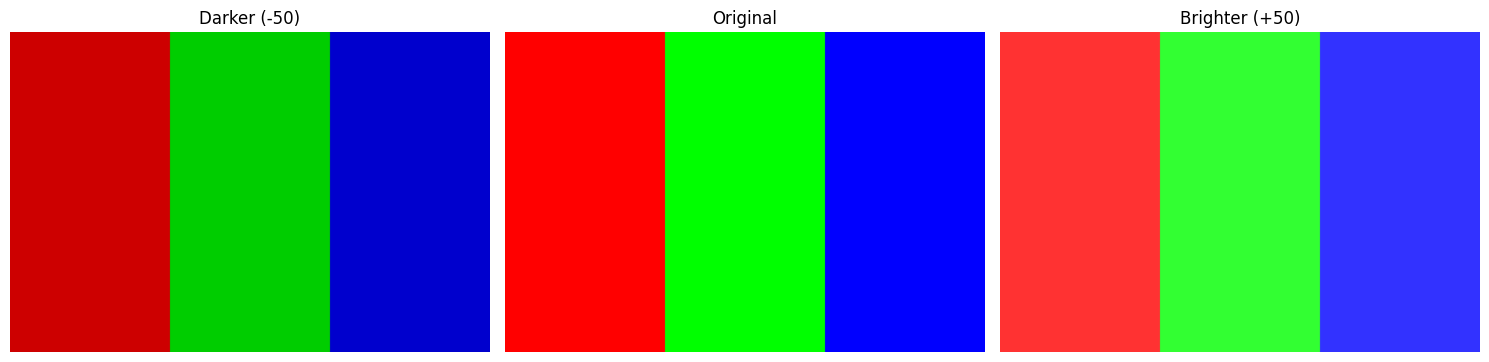

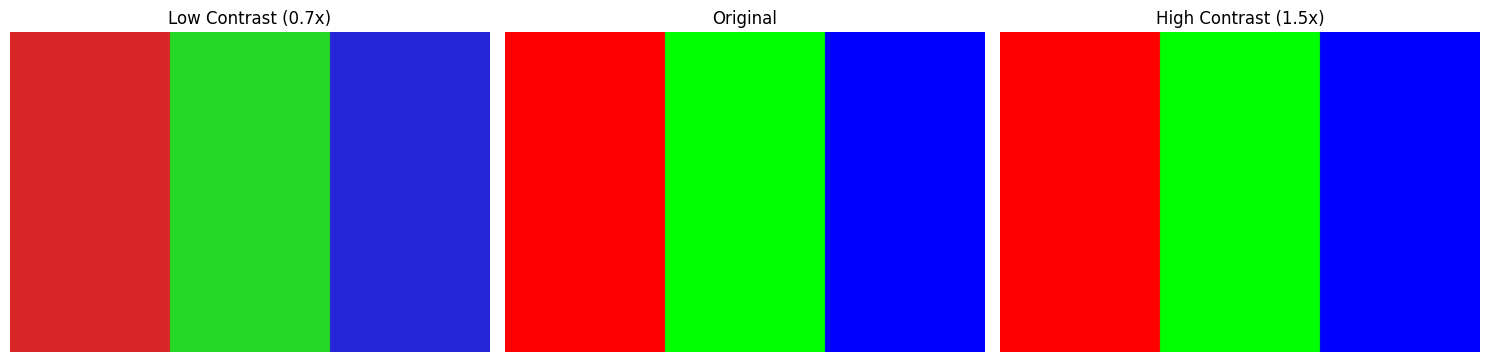

In [8]:
# Visualization: Brightness comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(dark_rgb)
axes[0].set_title("Darker (-50)")
axes[0].axis('off')

axes[1].imshow(rgb_image)
axes[1].set_title("Original")
axes[1].axis('off')

axes[2].imshow(bright_rgb)
axes[2].set_title("Brighter (+50)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Visualization: Contrast comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(low_contrast_rgb)
axes[0].set_title("Low Contrast (0.7x)")
axes[0].axis('off')

axes[1].imshow(rgb_image)
axes[1].set_title("Original")
axes[1].axis('off')

axes[2].imshow(high_contrast_rgb)
axes[2].set_title("High Contrast (1.5x)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

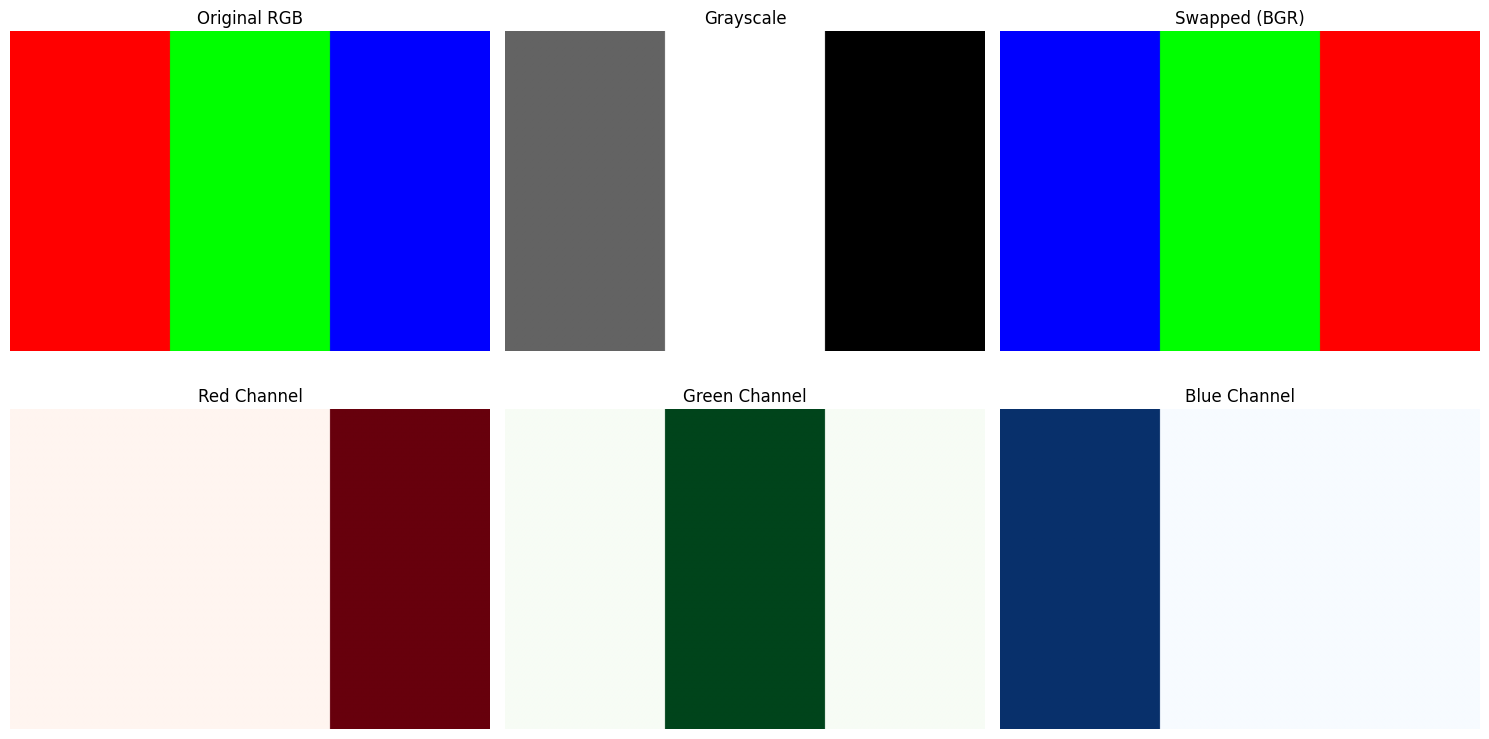

In [9]:
# Visualization: Channel operations
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Row 1: Original and channel-separated
axes[0, 0].imshow(rgb_image)
axes[0, 0].set_title("Original RGB")
axes[0, 0].axis('off')

axes[0, 1].imshow(cv2.cvtColor(rgb_image, cv2.COLOR_RGB2GRAY), cmap='gray')
axes[0, 1].set_title("Grayscale")
axes[0, 1].axis('off')

axes[0, 2].imshow(swapped_rgb)
axes[0, 2].set_title("Swapped (BGR)")
axes[0, 2].axis('off')

# Row 2: Individual color channels
b, g, r = cv2.split(rgb_image)
axes[1, 0].imshow(r, cmap='Reds')
axes[1, 0].set_title("Red Channel")
axes[1, 0].axis('off')

axes[1, 1].imshow(g, cmap='Greens')
axes[1, 1].set_title("Green Channel")
axes[1, 1].axis('off')

axes[1, 2].imshow(b, cmap='Blues')
axes[1, 2].set_title("Blue Channel")
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

---

## Deliverable: Complete Image Manipulation Script

A comprehensive tool combining all operations for image editing.

In [10]:
class ImageManipulator:
    """
    Comprehensive image manipulation tool supporting:
    - Brightness and contrast adjustments
    - Color channel operations
    - Format conversions
    - File I/O
    """
    
    def __init__(self, image_path=None, image_array=None):
        """
        Initialize with either a file path or a NumPy array.
        """
        if image_path is not None:
            self.image = cv2.imread(image_path)
            if self.image is None:
                raise ValueError(f"Could not read image from {image_path}")
            self.original = self.image.copy()
            print(f"✓ Loaded image from {image_path}")
        elif image_array is not None:
            self.image = image_array.copy()
            self.original = image_array.copy()
            print(f"✓ Initialized with array of shape {image_array.shape}")
        else:
            raise ValueError("Provide either image_path or image_array")
    
    def get_info(self):
        """Display image information."""
        h, w = self.image.shape[:2]
        channels = self.image.shape[2] if len(self.image.shape) == 3 else 1
        dtype = self.image.dtype
        
        print(f"Shape: {h} × {w} × {channels}")
        print(f"Data type: {dtype}")
        print(f"Value range: {self.image.min()} - {self.image.max()}")
        print(f"Memory: {self.image.nbytes / (1024*1024):.2f} MB")
    
    def reset(self):
        """Reset to original image."""
        self.image = self.original.copy()
        return self
    
    def brightness(self, factor):
        """
        Adjust brightness.
        factor > 0: increase, factor < 0: decrease
        """
        img_float = self.image.astype(np.float32)
        adjusted = np.clip(img_float + factor, 0, 255)
        self.image = adjusted.astype(np.uint8)
        return self
    
    def contrast(self, factor):
        """
        Adjust contrast.
        factor > 1: increase, factor < 1: decrease
        """
        img_float = self.image.astype(np.float32)
        middle_gray = 127.5
        adjusted = np.clip(middle_gray + factor * (img_float - middle_gray), 0, 255)
        self.image = adjusted.astype(np.uint8)
        return self
    
    def swap_channels(self, order):
        """
        Swap color channels.
        order: tuple like (2, 1, 0) for BGR→RGB
        """
        if len(self.image.shape) == 3 and self.image.shape[2] == 3:
            self.image = self.image[:, :, order]
        return self
    
    def enhance_channel(self, channel_idx, factor):
        """
        Enhance a specific color channel.
        channel_idx: 0 (first), 1 (second), 2 (third)
        """
        if len(self.image.shape) == 3 and self.image.shape[2] > channel_idx:
            img_float = self.image.astype(np.float32)
            img_float[:, :, channel_idx] = np.clip(
                img_float[:, :, channel_idx] * factor, 0, 255
            )
            self.image = img_float.astype(np.uint8)
        return self
    
    def to_grayscale(self):
        """Convert to grayscale."""
        if len(self.image.shape) == 3:
            self.image = cv2.cvtColor(self.image, cv2.COLOR_BGR2GRAY)
        return self
    
    def to_bgr(self):
        """Convert grayscale to BGR."""
        if len(self.image.shape) == 2:
            self.image = cv2.cvtColor(self.image, cv2.COLOR_GRAY2BGR)
        return self
    
    def save(self, output_path):
        """Save the current image."""
        cv2.imwrite(output_path, self.image)
        print(f"✓ Saved to {output_path}")
        return self
    
    def display(self, title="Image"):
        """Display the current image using Matplotlib."""
        if len(self.image.shape) == 3:
            # BGR to RGB for proper color display
            img_display = cv2.cvtColor(self.image, cv2.COLOR_BGR2RGB)
        else:
            img_display = self.image
        
        plt.figure(figsize=(8, 6))
        if len(img_display.shape) == 3:
            plt.imshow(img_display)
        else:
            plt.imshow(img_display, cmap='gray')
        plt.title(title)
        plt.axis('off')
        plt.show()
        return self
    
    def compare(self, title="Comparison"):
        """Compare original and modified images."""
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        for ax, img, lbl in zip(
            axes,
            [self.original, self.image],
            ["Original", "Modified"]
        ):
            if len(img.shape) == 3:
                display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            else:
                display_img = img
            
            if len(display_img.shape) == 3:
                ax.imshow(display_img)
            else:
                ax.imshow(display_img, cmap='gray')
            ax.set_title(lbl)
            ax.axis('off')
        
        fig.suptitle(title)
        plt.tight_layout()
        plt.show()
        return self
    
    def get_array(self):
        """Return the current image as a NumPy array."""
        return self.image.copy()

### Usage Examples

In [11]:
# Example 1: Create manipulator from array
manipulator = ImageManipulator(image_array=rgb_image)
manipulator.get_info()

✓ Initialized with array of shape (200, 300, 3)
Shape: 200 × 300 × 3
Data type: uint8
Value range: 0 - 255
Memory: 0.17 MB


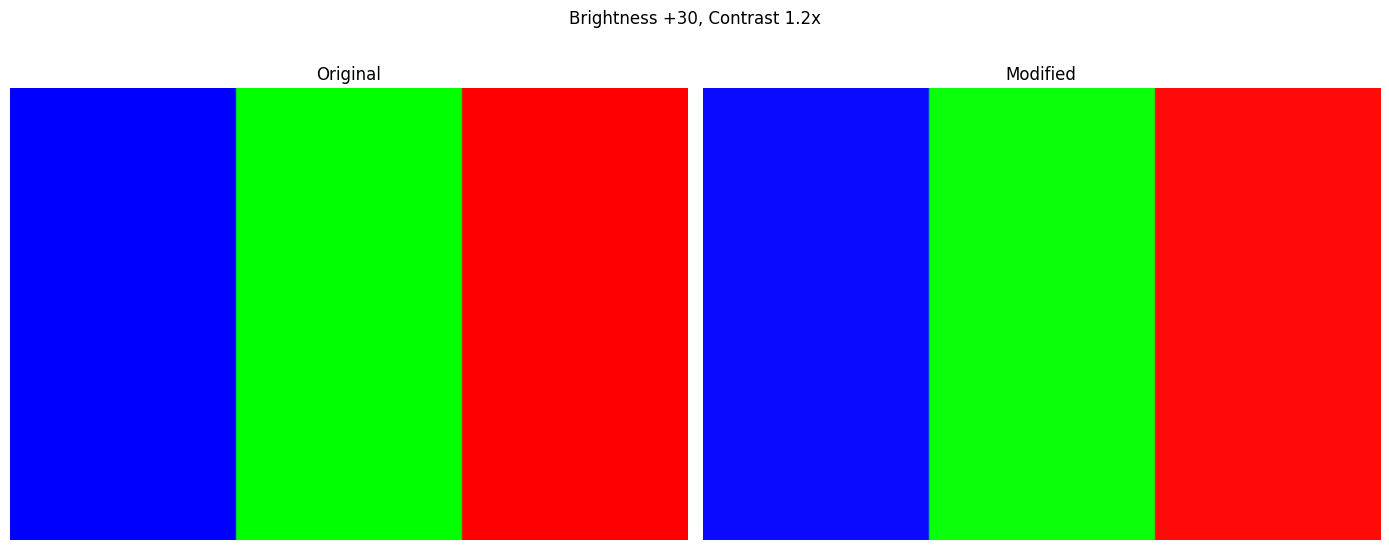

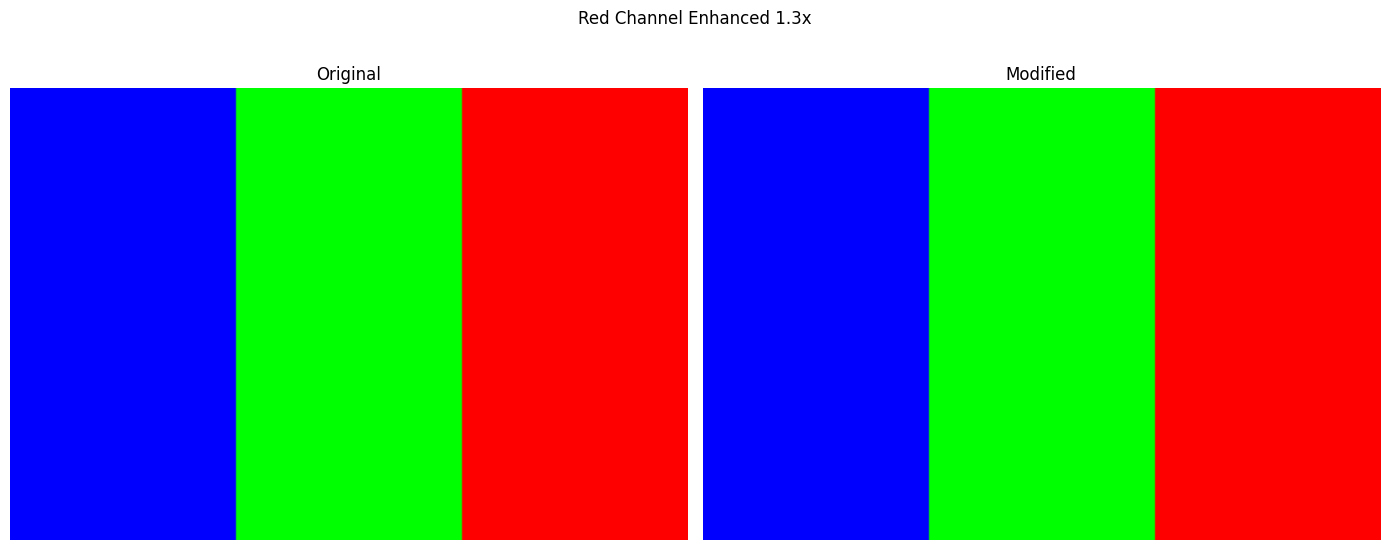

In [12]:
# Example 2: Brightness and Contrast adjustment with chaining
manipulator.reset().brightness(30).contrast(1.2).compare("Brightness +30, Contrast 1.2x")

# Example 3: Channel enhancement
manipulator.reset().enhance_channel(2, 1.3).compare("Red Channel Enhanced 1.3x")

In [13]:
# Example 4: Save results
manipulator.reset().brightness(20).save(os.path.join(test_dir, "brightened.png"))
manipulator.reset().contrast(1.3).save(os.path.join(test_dir, "high_contrast.png"))
manipulator.reset().enhance_channel(1, 1.2).save(os.path.join(test_dir, "green_enhanced.png"))

print("\nAll manipulated images saved to:", test_dir)

✓ Saved to test_images\brightened.png
✓ Saved to test_images\high_contrast.png
✓ Saved to test_images\green_enhanced.png

All manipulated images saved to: test_images


---

## Summary

### Key Concepts Covered:
1. **Images as Arrays**: Images are represented as NumPy arrays
   - Grayscale: 2D arrays (height, width)
   - Color: 3D arrays (height, width, channels)

2. **Color Channels**: 
   - RGB: Red, Green, Blue
   - BGR: OpenCV's default format (Blue, Green, Red)
   - Grayscale: Single channel

3. **File I/O**: Reading and writing images with OpenCV
   - `cv2.imread()`: Read images
   - `cv2.imwrite()`: Write images
   - Format conversions between RGB, BGR, and Grayscale

4. **Pixel Manipulation**:
   - **Brightness**: Add/subtract constant to all pixels
   - **Contrast**: Scale pixels around middle gray value
   - **Channel Operations**: Extract, enhance, or swap channels

5. **Visualization**: Using Matplotlib for displaying images

### The ImageManipulator Class:
A reusable tool that combines all operations with:
- Chainable methods for fluent API
- Brightness/contrast adjustment
- Channel operations
- Format conversions
- File I/O
- Side-by-side comparison

This provides a complete foundation for image processing in computer vision applications!